In [149]:
import pandas as pd
import numpy as np

In [150]:
df = pd.read_csv('train.csv')
df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [151]:
df['Activity'].value_counts()

Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

In [152]:
df.shape

(7352, 563)

In [153]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


# Seperate features and target
x = df.drop(columns=['Activity'],axis=1)
y = df['Activity']

# Encode target labels
le = LabelEncoder()
y = le.fit_transform(y)

# split dat into training and testing sets
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [154]:
print(x_train.shape)
print(y_train.shape)

(5881, 562)
(5881,)


In [155]:
print(x_test.shape)
print(y_test.shape)

(1471, 562)
(1471,)


# Applying Logistic Regression

In [156]:
# Initialize and train logistic regression
log_reg = LogisticRegression(max_iter=1000)
# Increase max_iter if it doesn't converge

log_reg.fit(x_train,y_train)

# make prediction on the test set
y_pred = log_reg.predict(x_test)

# calculate the accuracy score
accuracy = accuracy_score(y_test,y_pred)
print('Test accuracy:',accuracy)

Test accuracy: 0.981645139360979


### 1. Removing Duplicates Columns

In [157]:
# import time
# def get_duplicate_columns(df):
    
#     duplicate_columns = {}
#     seen_columns = {}

#     for column in df.columns:
#         current_column = df[column]

#         # Convert column data to bytes
#         try:
#             current_column_hash = current_column.values.tobytes()
#         except AttributeError:
#             current_column_hash = current_column.to_string().encode()

#         if current_column_hash in seen_columns:
#             if seen_columns[current_column_hash] in duplicate_columns:
#                 duplicate_columns[seen_columns[current_column_hash]].append(column)
#             else:
#                 duplicate_columns[seen_columns[current_column_hash]] = [column]
#         else:
#             seen_columns[current_column_hash] = column

#     return duplicate_columns

import time
start = time.time()
x_train = x_train.T
x_test = x_test.T
time.time()-start

0.025959491729736328

In [158]:
x_train.drop_duplicates(inplace=True)
x_test.drop_duplicates(inplace=True)

In [159]:
x_train = x_train.T
x_test = x_test.T

In [160]:
# start = time.time()
# duplicate_columns = get_duplicate_columns(x_train)
# time.time()-start

In [161]:
# duplicate_columns

In [162]:
# df[['tBodyAccMag-mean()','tBodyAccMag-sma()',
#   'tGravityAccMag-mean()',
#   'tGravityAccMag-sma()']]

In [163]:
# for one_list in duplicate_columns.values():
#     x_train.drop(columns=one_list,inplace=True)
#     x_test.drop(columns=one_list,inplace=True)

In [164]:
print(x_train.shape)
print(x_test.shape)

(5881, 541)
(1471, 541)


### 2. Variance Threshold

In [165]:
from sklearn.feature_selection import  VarianceThreshold
sel = VarianceThreshold(threshold=0.05)

In [166]:
sel.fit(x_train)

VarianceThreshold(threshold=0.05)

In [167]:
# remaining features
sum(sel.get_support())

np.int64(350)

In [168]:
columns = x_train.columns[sel.get_support()]

In [169]:
columns

Index(['tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X', 'tBodyAcc-max()-Y', 'tBodyAcc-max()-Z',
       'tBodyAcc-min()-X',
       ...
       'fBodyBodyGyroJerkMag-skewness()', 'fBodyBodyGyroJerkMag-kurtosis()',
       'angle(tBodyAccMean,gravity)', 'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'subject'],
      dtype='object', length=350)

In [170]:
x_train = sel.transform(x_train)
x_test = sel.transform(x_test)

x_train = pd.DataFrame(x_train,columns=columns)
x_test = pd.DataFrame(x_test,columns=columns)

In [171]:
print(x_train.shape)
print(x_test.shape)

(5881, 350)
(1471, 350)


### 3. Correlation

In [172]:
import seaborn as sns

<Axes: >

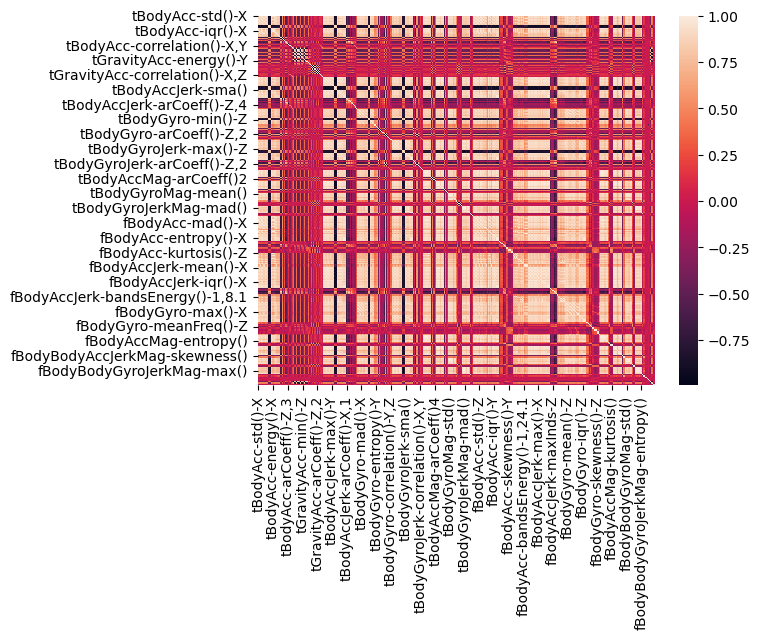

In [173]:
sns.heatmap(x_train.corr())

In [174]:
corr_matrix = x_train.corr()

In [175]:
# get the column names of the dataframe
columns = corr_matrix.columns

# create an empty list to keep track of columns to drop
columns_to_drop = []

# loop over the columns
for i in range(len(columns)):
    for j in range(i+1,len(columns)):
        # access the cell of the dataframe
        if corr_matrix.loc[columns[i],columns[j]] > 0.95:
            columns_to_drop.append(columns[j])

print(len(columns_to_drop))

1508


In [176]:
columns_to_drop = set(columns_to_drop)

In [177]:
len(columns_to_drop)

197

In [178]:
x_train.drop(columns=columns_to_drop,axis=1,inplace=True)
x_test.drop(columns=columns_to_drop,axis=1,inplace=True)

In [179]:
print(x_train.shape)
print(x_test.shape)

(5881, 153)
(1471, 153)


### 4. ANOVA

In [182]:
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import SelectKBest

sel = SelectKBest(f_classif,k=100)
sel.fit(x_train,y_train)

# display selected feature names
x_train.columns[sel.get_support()]

Index(['tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-max()-Z', 'tBodyAcc-min()-X', 'tBodyAcc-min()-Y',
       'tBodyAcc-min()-Z', 'tBodyAcc-entropy()-X', 'tBodyAcc-entropy()-Y',
       'tBodyAcc-entropy()-Z', 'tBodyAcc-arCoeff()-X,1',
       'tBodyAcc-arCoeff()-X,2', 'tBodyAcc-arCoeff()-X,3',
       'tBodyAcc-arCoeff()-Y,1', 'tBodyAcc-arCoeff()-Z,1',
       'tBodyAcc-correlation()-X,Y', 'tBodyAcc-correlation()-Y,Z',
       'tGravityAcc-mean()-X', 'tGravityAcc-mean()-Y', 'tGravityAcc-mean()-Z',
       'tGravityAcc-sma()', 'tGravityAcc-energy()-Y', 'tGravityAcc-energy()-Z',
       'tGravityAcc-entropy()-X', 'tGravityAcc-entropy()-Y',
       'tGravityAcc-arCoeff()-Y,1', 'tGravityAcc-arCoeff()-Y,2',
       'tGravityAcc-arCoeff()-Z,1', 'tGravityAcc-arCoeff()-Z,2',
       'tGravityAcc-correlation()-Y,Z', 'tBodyAccJerk-std()-Z',
       'tBodyAccJerk-min()-X', 'tBodyAccJerk-min()-Y', 'tBodyAccJerk-min()-Z',
       'tBodyAccJerk-entropy()-X', 'tBodyAccJerk-arCoeff

In [183]:
columns = x_train.columns[sel.get_support()]

In [184]:
x_train = sel.transform(x_train)
x_test = sel.transform(x_test)

x_train = pd.DataFrame(x_train,columns=columns)
x_test = pd.DataFrame(x_test,columns=columns)

In [185]:
print(x_train.shape)
print(x_test.shape)

(5881, 100)
(1471, 100)


In [186]:
x_train.head()

,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-max()-Z,tBodyAcc-min()-X,tBodyAcc-min()-Y,tBodyAcc-min()-Z,tBodyAcc-entropy()-X,tBodyAcc-entropy()-Y,tBodyAcc-entropy()-Z,...,fBodyGyro-meanFreq()-Z,"fBodyGyro-bandsEnergy()-1,8.1",fBodyAccMag-maxInds,fBodyBodyAccJerkMag-min(),fBodyBodyAccJerkMag-meanFreq(),fBodyBodyAccJerkMag-skewness(),fBodyBodyGyroMag-meanFreq(),"angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,-0.994425,-0.994873,-0.994886,-0.813863,0.846922,0.691468,0.846423,-0.611174,-0.768785,-0.663066,...,-0.158283,-0.999962,0.172414,-0.986305,0.132640,-0.690000,-0.024257,0.398881,-0.546717,-0.431200
1,-0.326331,0.069663,-0.224321,-0.411806,0.271334,0.039452,0.269204,0.403663,0.180054,0.176069,...,-0.315738,-0.898022,-0.517241,-0.718822,0.144767,-0.316666,0.191186,-0.474013,0.383162,0.238969
2,-0.026220,-0.032163,0.393109,0.200747,0.118277,0.072295,0.245986,0.318557,0.135103,0.087680,...,-0.071045,0.192158,-0.793103,-0.290424,-0.088077,-0.270995,-0.431985,-0.819001,0.221549,-0.003571
3,-0.981092,-0.901124,-0.960423,-0.807362,0.825370,0.642789,0.815368,-0.376515,-0.171730,-0.496816,...,-0.629423,-0.996263,-0.931034,-0.997886,-0.027783,-0.651181,-0.567748,-0.744428,0.274256,0.031246
4,-0.997380,-0.983893,-0.984482,-0.810993,0.853330,0.687431,0.844895,-0.652548,-0.678458,-0.486837,...,0.261846,-0.999927,-1.000000,-0.988139,0.668020,-0.598248,-0.257360,-0.615329,0.322236,0.161577


#### Moment of Truth

In [188]:
# Initialize and train logistic regression model
log_reg = LogisticRegression(max_iter=1000)
# Increase max_iter if it doesn't converge

log_reg.fit(x_train,y_train)

# make prediction on the test set
y_pred = log_reg.predict(x_test)

#calculate accuracy score 
accuracy = accuracy_score(y_test,y_pred)
print('Accuracy Score : ',accuracy)

Accuracy Score :  0.9687287559483345


In [189]:
titanic = pd.read_csv('titanic.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 5. Chi-Square Test

In [190]:
ct = pd.crosstab(titanic['Survived'],titanic['Sex'],margins=True)
ct

Sex,female,male,All
Survived,,,
0,81,468,549
1,233,109,342
All,314,577,891


In [191]:
from scipy.stats import chi2_contingency
chi2_contingency(ct)

Chi2ContingencyResult(statistic=np.float64(263.05057407065567), pvalue=np.float64(1.0036732821369117e-55), dof=4, expected_freq=array([[193.47474747, 355.52525253, 549.        ],
       [120.52525253, 221.47474747, 342.        ],
       [314.        , 577.        , 891.        ]]))

In [193]:
score = []

for feature in titanic.columns[:-1]:

    # create contingency table
    ct = pd.crosstab(titanic['Survived'],titanic[feature])

    # chi_test
    p_value = chi2_contingency(ct)[1]
    score.append(p_value)

<Axes: >

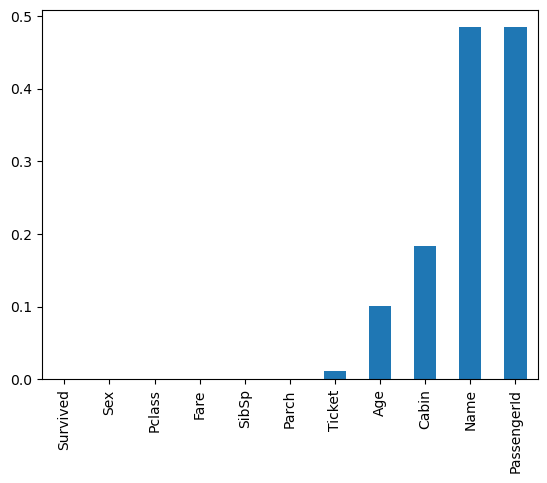

In [194]:
pd.Series(score,index=titanic.columns[:-1]).sort_values(ascending=True).plot(kind='bar')

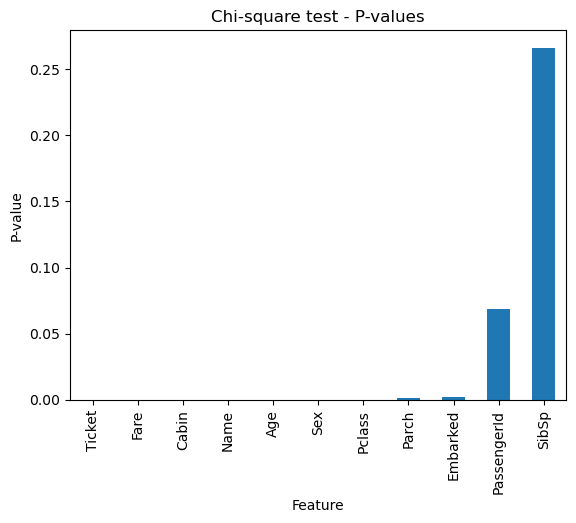

In [195]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2
import matplotlib.pyplot as plt

# assuming titanic is your DataFrame and 'Survived' is the target column

# Encode categorical variables
le = LabelEncoder()
titanic_encoded = titanic.apply(le.fit_transform)

X = titanic_encoded.drop('Survived', axis=1)
y = titanic_encoded['Survived']

# Calculate chi-squared stats
chi_scores = chi2(X, y)

# chi_scores[1] are the p-values of each feature.
p_values = pd.Series(chi_scores[1], index = X.columns)
p_values.sort_values(inplace = True)

# Plotting the p-values
p_values.plot.bar()

plt.title('Chi-square test - P-values')
plt.xlabel('Feature')
plt.ylabel('P-value')

plt.show()